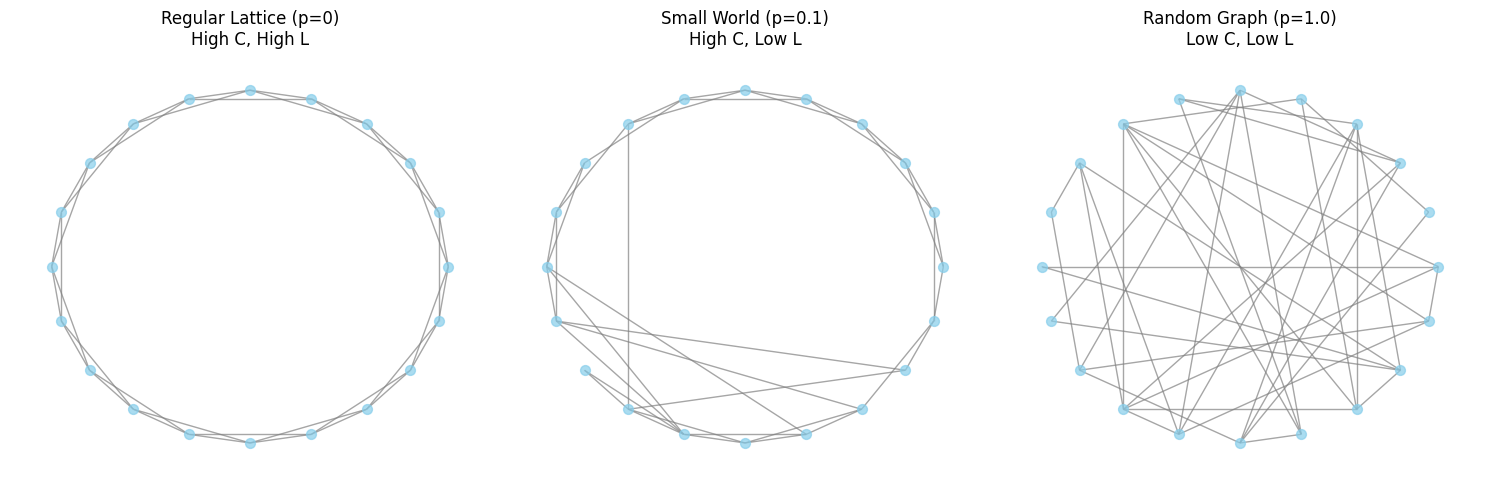

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def illustrate_small_world():
    # --- PARAMETERS ---
    n = 20  # Number of people (nodes) in our social network
    k = 4   # Each person is connected to 4 nearest neighbors initially
    p_values = [0, 0.1, 1.0]  # Rewiring probabilities (Regular, Small-World, Random)

    plt.figure(figsize=(15, 5))

    for i, p in enumerate(p_values):
        # 1. GENERATION
        # Formula/Logic: The Watts-Strogatz Graph
        # We start with a ring lattice. For every edge, with probability 'p',
        # we rewire one end to a random node.
        G = nx.watts_strogatz_graph(n, k, p)

        # 2. METRICS (The "Small World" Identifiers)
        # Average Path Length (L): The average number of steps between any two nodes.
        # Formula: L = 1 / (n * (n-1)) * sum(d(i, j)) where d is the shortest path.
        avg_path = nx.average_shortest_path_length(G)

        # Clustering Coefficient (C): Probability that two friends of a person are also friends.
        # Formula: C = (number of triangles) / (number of connected triplets)
        avg_clustering = nx.average_clustering(G)

        # 3. VISUALIZATION
        plt.subplot(1, 3, i+1)
        pos = nx.circular_layout(G) # Keep nodes in a circle to see rewiring clearly

        title = ""
        if p == 0:
            title = f"Regular Lattice (p={p})\nHigh C, High L"
        elif p < 1:
            title = f"Small World (p={p})\nHigh C, Low L"
        else:
            title = f"Random Graph (p={p})\nLow C, Low L"

        nx.draw(G, pos, node_size=50, node_color='skyblue', edge_color='gray', alpha=0.7)
        plt.title(title)
        plt.xlabel(f"Clustering (C): {avg_clustering:.2f}\nAvg Path (L): {avg_path:.2f}")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    illustrate_small_world()

As you'll see in the graphs generated:

Regular Lattice ($p=0$): High clustering (you know your neighbors), but high path length (it takes forever to reach someone on the other side of the circle).

Random Graph ($p=1$): Low path length (easy to get around), but low clustering (no stable social groups).

Small World ($0 < p < 0.2$): This is where social networks live. By adding just a few "random" acquaintances (long-range shortcuts), we keep our tight-knit friend groups while drastically shrinking the distance between any two people on Earth.

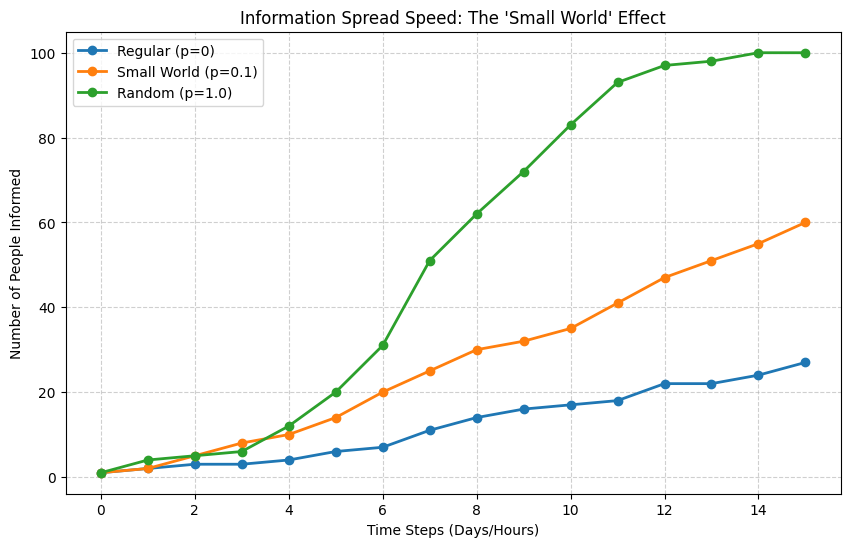

In [2]:
def simulate_spread(G, beta=0.3, steps=15):
    """
    Simulates the SI model: Susceptible nodes become Informed.
    Formula: Prob(Node i becomes informed) = 1 - (1 - beta)^k
    Where k = number of informed neighbors.
    """
    # Start with one random person knowing the 'information'
    informed = {np.random.choice(list(G.nodes()))}
    history = [len(informed)]

    for _ in range(steps):
        new_informed = set()
        for node in G.nodes():
            if node not in informed:
                # Count how many neighbors already know the info
                neighbors_informed = len(set(G.neighbors(node)) & informed)

                # Formula: Probability of infection from 'k' neighbors
                # If beta is the chance from one friend, the chance of NOT
                # hearing it from anyone is (1-beta)^k.
                prob_spread = 1 - (1 - beta)**neighbors_informed

                if np.random.random() < prob_spread:
                    new_informed.add(node)

        informed.update(new_informed)
        history.append(len(informed))
    return history

# --- EXECUTION & VISUALIZATION ---
plt.figure(figsize=(10, 6))
labels = ["Regular (p=0)", "Small World (p=0.1)", "Random (p=1.0)"]
n, k = 100, 4  # Larger N for better spread visualization

for i, p in enumerate([0, 0.1, 1.0]):
    G = nx.watts_strogatz_graph(n, k, p)
    spread_data = simulate_spread(G)
    plt.plot(spread_data, label=labels[i], marker='o', linewidth=2)

plt.title("Information Spread Speed: The 'Small World' Effect")
plt.xlabel("Time Steps (Days/Hours)")
plt.ylabel("Number of People Informed")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Why the "Small World" wins

The speed of information flow is mathematically tied to the Average Path Length ($L$)

Regular Lattice ($p=0$): Information travels like a "wave" through a crowd. It is slow because it must pass through every single person in a line to reach the other side.

Small World ($p=0.1$): Even though $90\%$ of connections are still local, the $10\%$ "shortcuts" act as information superhighways. These few random links drastically reduce the "Degrees of Separation," allowing the information to leapfrog across clusters.

Random Graph ($p=1$): Spread is also very fast here, but in a real social context, these networks lack the "trust" or "cliques" (clustering) that keep social groups stable.